# **Assignment 06: Stable Diffusion**

**Available:** Sep 30, 2025 3:00pm until Oct 9, 2025 11:59pm

**Details**
- https://huggingface.co/datasets/Gustavosta/Stable-Diffusion-Prompts/viewer/default/test?views%5B%5D=test
    - Go to the "People" section in the webcourse​
    - If you are the first student, for example, you will take the first 10 prompts from above link, second student will take the 11-20th prompts in the list and so on​
- Run SDXL Turbo and SDXL on those prompts assigned to you​
- Compare both models with two metrics​
    - FID​
    - Speed ​
- Report due 10/9

## **Setup**

In [1]:
## Import Libraries

# Set CUDA_VISIBLE_DEVICES to make both GPUs visible
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

# Install all packages for from the requirements.txt
%pip install -r requirements.txt

import torch
import torch.nn as nn
import torchvision
import datasets
import cv2
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch import optim
from tqdm.notebook import tqdm
from torchinfo import summary
import einops
import PIL
import numpy as np
import pandas as pd
# Use a pipeline as a high-level helper
from transformers import pipeline
import time
import psutil
import gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from collections import defaultdict
import numpy as np

# Authorize Huggingface account
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('/mnt/Storage02/SoftwareDev/CAP_6411_Assignments/.env')

# Get Hugging Face token
hf_token = os.getenv('HUGGINGFACE_HUB_TOKEN') or os.getenv('HF_TOKEN')

if hf_token:
    print("Found Hugging Face token in environment variables")
    
    
    from huggingface_hub import login, whoami
    
    try:
        # Login to Hugging Face Hub
        login(token=hf_token)
        
        # Verify login by getting user info
        user_info = whoami()
        print(f"Successfully authenticated with Hugging Face!")
        print(f"Logged in as: {user_info['name']}")
        
        # Set the token as environment variable for other libraries
        os.environ['HUGGINGFACE_HUB_TOKEN'] = hf_token
        os.environ['HF_TOKEN'] = hf_token
        
    except Exception as e:
        print(f"Authentication failed: {e}")
        print("Will proceed without pre-trained models if needed")
        hf_token = None
else:
    print("No Hugging Face token found in .env file")
    print("Please add HUGGINGFACE_HUB_TOKEN=your_token_here to your .env file")
    hf_token = None


# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Found Hugging Face token in environment variables
Found Hugging Face token in environment variables


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Successfully authenticated with Hugging Face!
Logged in as: malneyugnfl


In [2]:
# GPU Setup 
# Comprehensive GPU diagnostics
print("\n=== GPU Diagnostics ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs detected: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print("\n=== All Available GPUs ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1024**3:.2f} GB")
        print(f"  Multi-processor count: {props.multi_processor_count}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print()

# Device selection with preference for cuda:1 (A6000) -> cuda:0 (4090) -> mps (Apple Silicon) -> cpu
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # This should now be your A6000!
    print(f"Using GPU 1: {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Using GPU 0: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon MPS")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Selected device: {device}")

# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    elif device.type == 'mps':
        # MPS doesn't have direct memory monitoring like CUDA
        # Return 0 as a placeholder
        return 0
    return 0


=== GPU Diagnostics ===
PyTorch version: 2.8.0+cu128
CUDA available: True
MPS available: False
CUDA version: 12.8
Number of GPUs detected: 1

=== All Available GPUs ===
GPU 0:
  Name: NVIDIA GeForce RTX 4090 Laptop GPU
  Total Memory: 15.70 GB
  Multi-processor count: 76
  Compute Capability: 8.9

Using GPU 0: NVIDIA GeForce RTX 4090 Laptop GPU
Selected device: cuda:0


In [3]:
# Function to clear memory for both CUDA and MPS
def clear_memory():
    """Clear CPU and GPU memory"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
        torch.mps.empty_cache()
    print(f"Cleared memory. Current CPU memory usage: {get_memory_usage():.2f} MB, GPU memory usage: {get_gpu_memory_usage():.2f} MB")

In [4]:
# Stable Diffusion Prompts:

prompt_list = [
    
"a girl smiling, Tristan Eaton, victo ngai, artgerm, RHADS, ross draws",
"a character portrait of a cyborg super saiyan in the style of moebius in the style of yoji shinkawa trending on artstation deviantart pinterest detailed realistic hd 8 k high resolution",
"big hand holding skull and bones, illustrated by Simon Stålenhag and Gaston Bussiere, intricate, ultra detailed, photorealistic, trending on artstation",
"Her huge ominous glowing blue eyes staring into my soul , perfect eyes, soft pale white skin, intricate stunning highly detailed, agostino arrivabene, artgerm, twisted dark lucid dream, 8k portrait render, raven angel wings, swirling thick smoke , beautiful lighting, dark fantasy art, cgsociety",
"the prince of frost standing alone in his court, archfey, full - body portrait, fantasy, white hair, blue skin, wild eyebrows, young adult, elf, crown, hard edges, soft lighting, professional lighting, trending on artstation",
"male cottagecore snoop dogg, Calvin Cordozar Broadus Jr., intricate, swagger, highly detailed, digital painting, artstation, concept art, smooth, sharp, focus, illustration, art by artgerm and greg rutkowski and alphonse mucha",
"amazing lifelike award winning pencil illustration of bob dylan trending on art station artgerm greg rutkowski alphonse mucha cinematic",
"medium - shot vislor turlough played by mark strickson at age 1 8, beautiful, at the alien space pub bar counter, highly detailed, mood lighting, artstation, highly detailed digital painting, smooth, global illumination, fantasy art by greg rutkowsky, karl spitzweg, leyendecker",
"portal to the multiverse of infinite horror with freakish spider creatures leaking out by laurie greasley digital art, highly detailed, intricate, sharp focus, trending on artstation hq, deviantart, octane render, bump map, pinterest, unreal engine 5, 4 k uhd image",
"concept art of fractal shaped spaceship by Michal Klimczak, high detail, artstation CG society"

]

# **Import SDXL and Run Prompts**

In [5]:
# Import SDXL
# Source: https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0

from diffusers import DiffusionPipeline

with torch.no_grad():
    pipe = DiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-xl-base-1.0")
    pipe.to(device)



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
# Run Prompts

prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"
image = pipe(prompt).images[0]

plt.imshow(image)
plt.axis('off')  # Hide axes
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 1024.00 MiB. GPU 0 has a total capacity of 15.70 GiB of which 30.94 MiB is free. Including non-PyTorch memory, this process has 15.65 GiB memory in use. Of the allocated memory 14.83 GiB is allocated by PyTorch, and 554.02 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Delete Model
del pipe
clear_memory()

Cleared memory. Current CPU memory usage: 1049.54 MB, GPU memory usage: 0.00 MB


# **Import SDXL Turbo and Run Prompts**

In [7]:
# Import SDXL Turbo
# Source: https://huggingface.co/stabilityai/sdxl-turbo

from diffusers import AutoPipelineForText2Image

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to(device)




model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

text_encoder_2/model.fp16.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

scheduler_config.json:   0%|          | 0.00/459 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


StableDiffusionXLPipeline {
  "_class_name": "StableDiffusionXLPipeline",
  "_diffusers_version": "0.35.1",
  "_name_or_path": "stabilityai/sdxl-turbo",
  "feature_extractor": [
    null,
    null
  ],
  "force_zeros_for_empty_prompt": true,
  "image_encoder": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "EulerAncestralDiscreteScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "text_encoder_2": [
    "transformers",
    "CLIPTextModelWithProjection"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "tokenizer_2": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/1 [00:00<?, ?it/s]

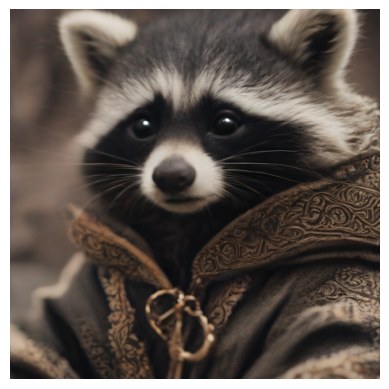

In [10]:
prompt = "A cinematic shot of a baby racoon wearing an intricate italian priest robe."

image = pipe(prompt=prompt, num_inference_steps=1, guidance_scale=0.0).images[0]

plt.imshow(image)
plt.axis('off')  # Hide axes
plt.show()


In [ ]:
# Delete Model
del pipe
clear_memory()